<b><h3>Model Training and Final Evaluation<b><h3>

<h3><b>1. Import Libraries and Configure Paths</b></h3>

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (
        path
        / "data"
        / "processed"
        / "concrete_data_cleaned.csv"
    ).exists()
)


DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "concrete_data_cleaned.csv"
)

MODELS_PATH = PROJECT_ROOT / "models"
REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH = REPORTS_PATH / "figures"


# Create folders if they do not exist
MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


print("Project Root:", PROJECT_ROOT)
print("Setup Complete")

Project Root: c:\Users\asus\Desktop\AIML\Concrete-Compressive-Strength-Predictor\Concrete-Compressive-Strength-Predictor
Setup Complete


<h3><b>2. Load the Cleaned Dataset</b></h3>

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (911, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cement                911 non-null    float64
 1   blast_furnace_slag    911 non-null    float64
 2   fly_ash               911 non-null    float64
 3   water                 911 non-null    float64
 4   superplasticizer      911 non-null    float64
 5   coarse_aggregate      911 non-null    float64
 6   fine_aggregate        911 non-null    float64
 7   age                   911 non-null    int64  
 8   compressive_strength  911 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 64.2 KB


<h3><b>3. Check the Dataset Before Model Training</b></h3>

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Missing Values:
cement                  0
blast_furnace_slag      0
fly_ash                 0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compressive_strength    0
dtype: int64

Duplicate Rows:
0

Dataset Shape:
(911, 9)

Columns:
['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'compressive_strength']


<h3><b>4. Separate Features and Target Variable</b></h3>

In [4]:
target_column = "compressive_strength"

X = df.drop(columns=[target_column])
y = df[target_column]


print("Input Features:")
print(X.columns.tolist())

print("\nNumber of Features:", X.shape[1])

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

display(X.head())

Input Features:
['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age']

Number of Features: 8

Feature Shape: (911, 8)
Target Shape: (911,)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28


<h3><b>5. Split the Dataset into Training and Testing Sets</b></h3>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)


print(
    f"\nTraining Data: {len(X_train)} samples "
    f"({len(X_train) / len(X) * 100:.1f}%)"
)

print(
    f"Testing Data: {len(X_test)} samples "
    f"({len(X_test) / len(X) * 100:.1f}%)"
)

Training Feature Shape: (728, 8)
Testing Feature Shape: (183, 8)
Training Target Shape: (728,)
Testing Target Shape: (183,)

Training Data: 728 samples (79.9%)
Testing Data: 183 samples (20.1%)


<h3><b>6. Create the Baseline Random Forest Regression Model,Train the Baseline Random Forest Model and Genarate Prediction</b></h3>

In [6]:
baseline_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


print(baseline_rf)

baseline_rf.fit(
    X_train,
    y_train
)

print("Baseline Random Forest training completed.")

baseline_train_predictions = baseline_rf.predict(X_train)

baseline_test_predictions = baseline_rf.predict(X_test)


print("Predictions generated successfully.")

RandomForestRegressor(n_jobs=-1, random_state=42)
Baseline Random Forest training completed.
Predictions generated successfully.


<h3><b>7. Evaluate the Baseline Random Forest Model</b></h3>

In [7]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_test_predictions
)

baseline_mse = mean_squared_error(
    y_test,
    baseline_test_predictions
)

baseline_rmse = np.sqrt(
    baseline_mse
)

baseline_r2 = r2_score(
    y_test,
    baseline_test_predictions
)


print("Baseline Random Forest Results")
print("-" * 40)

print(f"MAE  : {baseline_mae:.4f}")
print(f"MSE  : {baseline_mse:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Random Forest Results
----------------------------------------
MAE  : 3.1964
MSE  : 19.8771
RMSE : 4.4584
R²   : 0.9238


<h3><b>8. Compare Training and Testing Performance</b></h3>

In [8]:
train_r2 = r2_score(
    y_train,
    baseline_train_predictions
)

test_r2 = r2_score(
    y_test,
    baseline_test_predictions
)


print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")

print(f"Difference  : {train_r2 - test_r2:.4f}")

Training R² : 0.9813
Testing R²  : 0.9238
Difference  : 0.0574


<h3><b>9. Perform 5-Fold Cross Validation</b></h3>

In [9]:
cv_scores = cross_val_score(
    baseline_rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


print("Cross Validation R² Scores:")
print(cv_scores)

print(
    f"\nMean CV R²: "
    f"{cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{cv_scores.std():.4f}"
)

Cross Validation R² Scores:
[0.90427772 0.8750431  0.89250292 0.88852974 0.89878424]

Mean CV R²: 0.8918
Standard Deviation: 0.0100


<h3><b>10. Hyperparameter Tuning Using RandomizedSearchCV</b></h3>

In [10]:
parameter_grid = {

    "n_estimators": [100,200,300,500],

    "max_depth": [None,10,20,30],

    "min_samples_split": [2,5,10],

    "min_samples_leaf": [1,2,4],

    "max_features": [1.0,"sqrt","log2"]
}

rf_for_tuning = RandomForestRegressor(random_state=42,
n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=parameter_grid,

    n_iter=30,

    scoring="r2",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

print("\nHyperparameter tuning completed.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Hyperparameter tuning completed.


<h3><b>11. Display the Best Hyperparameters</b></h3>

In [11]:
print("Best Parameters:")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")


print(
    f"\nBest Cross Validation R²: "
    f"{random_search.best_score_:.4f}"
)

Best Parameters:
n_estimators: 200
min_samples_split: 2
min_samples_leaf: 1
max_features: 1.0
max_depth: 30

Best Cross Validation R²: 0.8934


<h3><b>12. Get the Tuned Random Forest Model</b></h3>

In [12]:
tuned_rf = random_search.best_estimator_

print("Best Random Forest Model:")

print(tuned_rf)

Best Random Forest Model:
RandomForestRegressor(max_depth=30, n_estimators=200, n_jobs=-1,
                      random_state=42)


<h3><b>13. Generate Predictions Using the Tuned Model</b></h3>

In [13]:
tuned_train_predictions = tuned_rf.predict(
    X_train
)

tuned_test_predictions = tuned_rf.predict(
    X_test
)


print("Predictions generated successfully.")

Predictions generated successfully.


<h3><b>14. Evaluate the Tuned Random Forest Model</b></h3>

In [14]:
tuned_mae = mean_absolute_error(
    y_test,
    tuned_test_predictions
)

tuned_mse = mean_squared_error(
    y_test,
    tuned_test_predictions
)

tuned_rmse = np.sqrt(
    tuned_mse
)

tuned_r2 = r2_score(
    y_test,
    tuned_test_predictions
)


print("Tuned Random Forest Results")
print("-" * 40)

print(f"MAE  : {tuned_mae:.4f}")
print(f"MSE  : {tuned_mse:.4f}")
print(f"RMSE : {tuned_rmse:.4f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned Random Forest Results
----------------------------------------
MAE  : 3.1411
MSE  : 19.0406
RMSE : 4.3636
R²   : 0.9270


<h3><b>15. Compare Baseline and Tuned Random Forest Models</b></h3>

In [15]:
comparison = pd.DataFrame({

    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],

    "MAE": [
        baseline_mae,
        tuned_mae
    ],

    "MSE": [
        baseline_mse,
        tuned_mse
    ],

    "RMSE": [
        baseline_rmse,
        tuned_rmse
    ],

    "R2": [
        baseline_r2,
        tuned_r2
    ]
})


display(
    comparison.round(4)
)

,Model,MAE,MSE,RMSE,R2
0,Baseline Random Forest,3.1964,19.8771,4.4584,0.9238
1,Tuned Random Forest,3.1411,19.0406,4.3636,0.9270


<h3><b>16. Select the Final Random Forest Model</b></h3>

In [16]:
if tuned_r2 >= baseline_r2:

    final_rf = tuned_rf
    final_predictions = tuned_test_predictions

    final_model_name = "Tuned Random Forest"

    final_mae = tuned_mae
    final_mse = tuned_mse
    final_rmse = tuned_rmse
    final_r2 = tuned_r2

else:

    final_rf = baseline_rf
    final_predictions = baseline_test_predictions

    final_model_name = "Baseline Random Forest"

    final_mae = baseline_mae
    final_mse = baseline_mse
    final_rmse = baseline_rmse
    final_r2 = baseline_r2


print("Final Model:", final_model_name)

print(f"MAE  : {final_mae:.4f}")
print(f"MSE  : {final_mse:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

Final Model: Tuned Random Forest
MAE  : 3.1411
MSE  : 19.0406
RMSE : 4.3636
R²   : 0.9270


<h3><b>17. Analyze Feature Importance</b></h3>

In [17]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        final_rf.feature_importances_

})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)


display(feature_importance)

,Feature,Importance
0,age,0.343025
1,cement,0.288281
2,water,0.125435
3,superplasticizer,0.081301
4,blast_furnace_slag,0.073546
5,fine_aggregate,0.038913
6,coarse_aggregate,0.029250
7,fly_ash,0.020250


<h3><b>18. Visualize Feature Importance</b></h3>

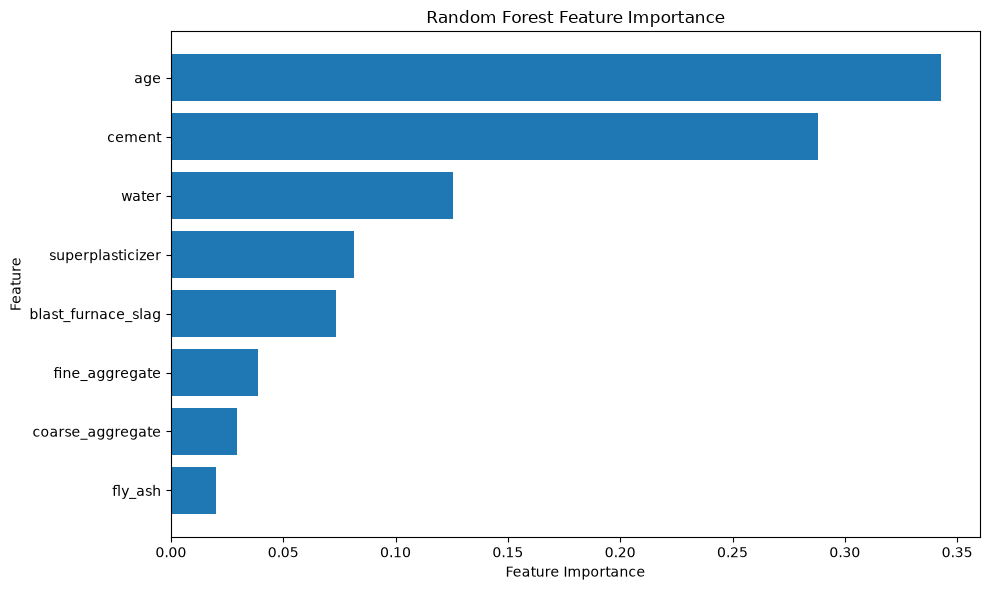

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()


plt.savefig(
    FIGURES_PATH
    / "random_forest_feature_importance.png",
    dpi=300
)


plt.show()

plt.close()

<h3><b>19. Compare Actual and Predicted Values</b></h3>

In [19]:
prediction_results = pd.DataFrame({

    "Actual Strength":
        y_test.to_numpy(),

    "Predicted Strength":
        final_predictions

})


prediction_results["Error"] = (
    prediction_results["Actual Strength"]
    - prediction_results["Predicted Strength"]
)


prediction_results["Absolute Error"] = (
    prediction_results["Error"].abs()
)


display(
    prediction_results.head(20)
)

,Actual Strength,Predicted Strength,Error,Absolute Error
0,42.42,41.314450,1.105550,1.105550
1,33.06,30.495550,2.564450,2.564450
2,20.28,18.577250,1.702750,1.702750
3,31.72,41.022900,-9.302900,9.302900
4,48.59,44.559650,4.030350,4.030350
5,12.46,11.711850,0.748150,0.748150
6,67.87,50.011500,17.858500,17.858500
7,22.53,24.180000,-1.650000,1.650000
8,58.61,55.829350,2.780650,2.780650
9,33.02,40.038550,-7.018550,7.018550


<h3><b>20. Actual vs Predicted Compressive Strength</b></h3>

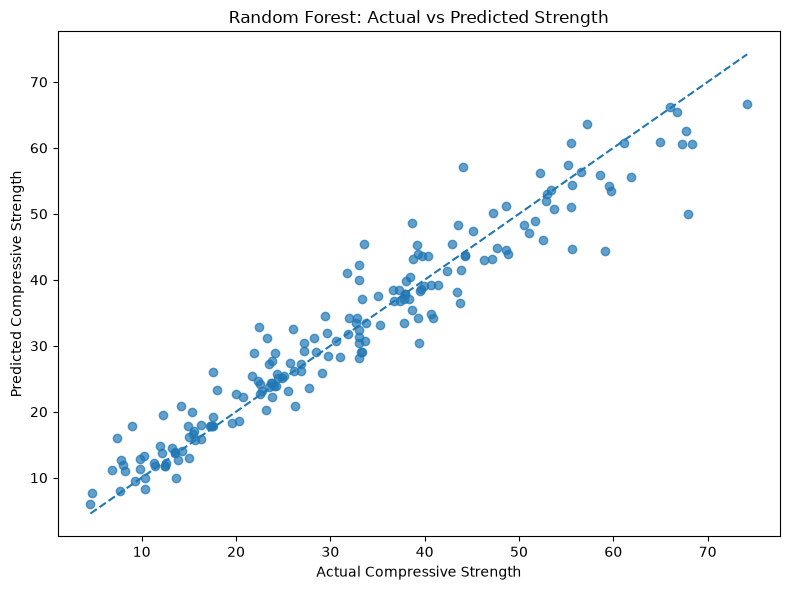

In [20]:
plt.figure(figsize=(8, 6))


plt.scatter(
    y_test,
    final_predictions,
    alpha=0.7
)


minimum_value = min(
    y_test.min(),
    final_predictions.min()
)

maximum_value = max(
    y_test.max(),
    final_predictions.max()
)


plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)


plt.xlabel(
    "Actual Compressive Strength"
)

plt.ylabel(
    "Predicted Compressive Strength"
)

plt.title(
    "Random Forest: Actual vs Predicted Strength"
)


plt.tight_layout()


plt.savefig(
    FIGURES_PATH
    / "random_forest_actual_vs_predicted.png",
    dpi=300
)


plt.show()

plt.close()

<h3><b>21. Residual Analysis</b></h3>

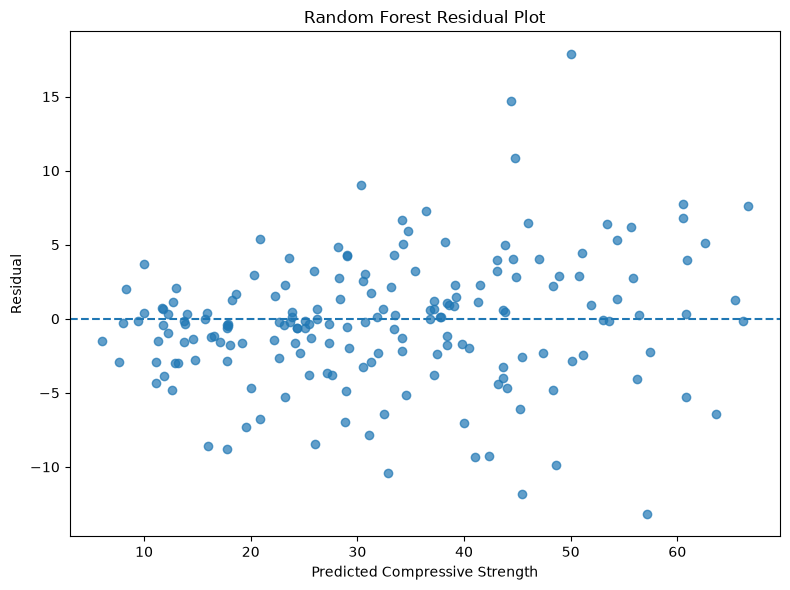

In [21]:
residuals = (
    y_test.to_numpy()
    - final_predictions
)

plt.figure(figsize=(8, 6))

plt.scatter(final_predictions,residuals,alpha=0.7)

plt.axhline(y=0,linestyle="--")
plt.xlabel("Predicted Compressive Strength")
plt.ylabel("Residual")
plt.title("Random Forest Residual Plot")
plt.tight_layout()
plt.savefig(FIGURES_PATH/ "random_forest_residual_plot.png",dpi=300)

plt.show()
plt.close()

<h3><b>22. Distribution of Prediction Errors</b></h3>

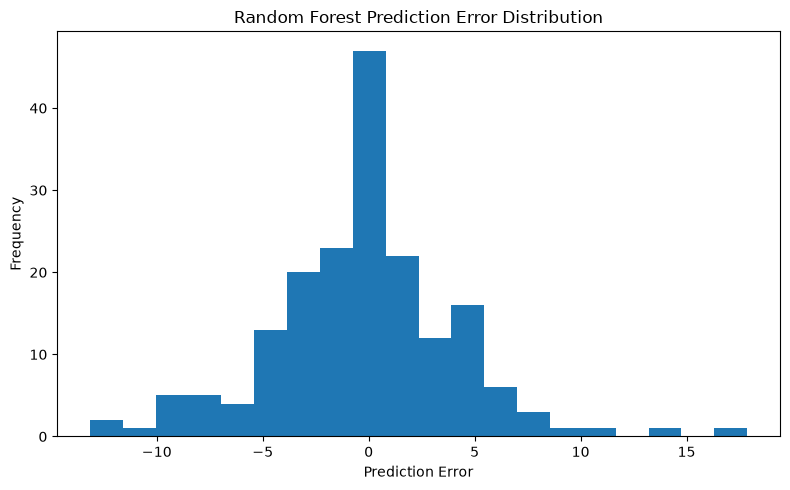

In [22]:
plt.figure(figsize=(8, 5))


plt.hist(residuals,bins=20)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Random Forest Prediction Error Distribution")
plt.tight_layout()


plt.savefig(FIGURES_PATH/ "random_forest_residual_distribution.png",dpi=300)

plt.show()
plt.close()

<h3><b>23. Save Random Forest Prediction Results</b></h3>

In [23]:
PREDICTION_PATH = (
    REPORTS_PATH
    / "random_forest_predictions.csv"
)


prediction_results.to_csv(
    PREDICTION_PATH,
    index=False
)


print(
    "Prediction results saved to:",
    PREDICTION_PATH
)

Prediction results saved to: c:\Users\asus\Desktop\AIML\Concrete-Compressive-Strength-Predictor\Concrete-Compressive-Strength-Predictor\reports\random_forest_predictions.csv


<h3><b>24. Save Random Forest Evaluation Results</b></h3>

In [24]:
model_results = pd.DataFrame({

    "Model": [
        "Random Forest Regression"
    ],

    "MAE": [
        final_mae
    ],

    "MSE": [
        final_mse
    ],

    "RMSE": [
        final_rmse
    ],

    "R2": [
        final_r2
    ]

})


RESULTS_PATH = (
    REPORTS_PATH
    / "random_forest_results.csv"
)


model_results.to_csv(
    RESULTS_PATH,
    index=False
)


display(
    model_results.round(4)
)


print(
    "Results saved to:",
    RESULTS_PATH
)

,Model,MAE,MSE,RMSE,R2
0,Random Forest Regression,3.1411,19.0406,4.3636,0.927


Results saved to: c:\Users\asus\Desktop\AIML\Concrete-Compressive-Strength-Predictor\Concrete-Compressive-Strength-Predictor\reports\random_forest_results.csv


<h3><b>25. Save the Final Random Forest Model</b></h3>


In [25]:
MODEL_PATH = (
    MODELS_PATH
    / "random_forest_regressor.joblib"
)


joblib.dump(
    final_rf,
    MODEL_PATH
)


print(
    "Random Forest model saved to:",
    MODEL_PATH
)

Random Forest model saved to: c:\Users\asus\Desktop\AIML\Concrete-Compressive-Strength-Predictor\Concrete-Compressive-Strength-Predictor\models\random_forest_regressor.joblib


<h3><b>26. Load and Test the Saved Model</b></h3>

In [26]:
loaded_rf = joblib.load(
    MODEL_PATH
)


loaded_predictions = loaded_rf.predict(
    X_test
)


loaded_r2 = r2_score(
    y_test,
    loaded_predictions
)


print(
    f"Loaded Model R²: "
    f"{loaded_r2:.4f}"
)

print(
    "Random Forest model loaded successfully."
)

Loaded Model R²: 0.9270
Random Forest model loaded successfully.


<h3><b>27. Predict a New Concrete Sample</b></h3>

In [27]:
new_sample = pd.DataFrame({

    "cement": [540.0],

    "blast_furnace_slag": [0.0],

    "fly_ash": [0.0],

    "water": [162.0],

    "superplasticizer": [2.5],

    "coarse_aggregate": [1040.0],

    "fine_aggregate": [676.0],

    "age": [28]

})


predicted_strength = loaded_rf.predict(
    new_sample
)


print(
    "Predicted Concrete Compressive Strength:",
    round(predicted_strength[0], 2)
)

Predicted Concrete Compressive Strength: 60.18


<h3><b>28. Final Random Forest Regression Summary</b></h3>

In [28]:
print("=" * 60)
print("RANDOM FOREST REGRESSION SUMMARY")
print("=" * 60)
print(f"Total Dataset Samples: "f"{len(df)}")
print(f"Training Samples: "f"{len(X_train)}")
print(f"Testing Samples: "f"{len(X_test)}")
print(f"Number of Features: "f"{X.shape[1]}")
print(f"Final Model: "f"{final_model_name}")
print(f"MAE: "f"{final_mae:.4f}")
print(f"MSE: "f"{final_mse:.4f}")
print(f"RMSE: "f"{final_rmse:.4f}")
print(f"R² Score: "f"{final_r2:.4f}")
print("=" * 60)

RANDOM FOREST REGRESSION SUMMARY
Total Dataset Samples: 911
Training Samples: 728
Testing Samples: 183
Number of Features: 8
Final Model: Tuned Random Forest
MAE: 3.1411
MSE: 19.0406
RMSE: 4.3636
R² Score: 0.9270


In [29]:
MODEL_PATH = (
    MODELS_PATH
    / "trained"
    / "random_forest_regressor.joblib"
)

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_rf,
    MODEL_PATH
)

['c:\\Users\\asus\\Desktop\\AIML\\Concrete-Compressive-Strength-Predictor\\Concrete-Compressive-Strength-Predictor\\models\\trained\\random_forest_regressor.joblib']

In [30]:
train_pred = final_rf.predict(X_train)
test_pred = final_rf.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")
print(f"Difference  : {train_r2 - test_r2:.4f}")

Training R² : 0.9826
Testing R²  : 0.9270
Difference  : 0.0556
